# Task 3: Forecast Future Market Trends

In this notebook, the best-performing forecasting model (LSTM) is used to predict Tesla's adjusted closing price for the next 12 months. The generated forecast is visualized alongside historical prices and approximate confidence intervals to support portfolio decision-making.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from tensorflow.keras.models import load_model

from src.preprocessing import (
    scale_prices,
    create_sequences
)

from sklearn.preprocessing import MinMaxScaler

from src.data_loader import load_processed_data
from src.model_loader import load_lstm_model

from src.forecasting import (
    create_last_sequence,
    iterative_forecast,
    build_forecast_dataframe,
    add_confidence_interval,
    save_forecast
)

In [5]:
tsla = load_processed_data(
    "TSLA_processed.csv"
)

prices = tsla[["Adj Close"]]

In [ ]:
model = load_lstm_model()

In [6]:
scaler = MinMaxScaler()

scaled_prices = scaler.fit_transform(prices)

In [7]:
last_sequence = create_last_sequence(
    scaled_prices,
    window_size=60
)

In [8]:
future_prices = iterative_forecast(
    model=model,
    last_sequence=last_sequence,
    scaler=scaler,
    days=252
)

In [9]:
forecast_df = build_forecast_dataframe(
    last_date=tsla.index[-1],
    forecasts=future_prices
)

In [11]:
prediction_df = pd.read_csv(
    "../data/processed/lstm_predictions.csv"
)

residual_std = (
    prediction_df["Actual"]
    - prediction_df["Prediction"]
).std()

In [12]:
forecast_df = add_confidence_interval(
    forecast_df,
    residual_std
)

In [13]:
save_forecast(forecast_df)

Forecast saved to:
C:\Users\sumex\Desktop\portfolio-optimization\data\processed\tsla_future_forecast.csv


In [14]:
forecast_df.head()

,Date,Forecast,Lower_CI,Upper_CI
0,2026-06-30,374.237274,271.786208,476.688340
1,2026-07-01,373.130127,228.242440,518.017814
2,2026-07-02,371.080597,193.630146,548.531048
3,2026-07-03,368.448761,163.546629,573.350892
4,2026-07-06,365.482361,136.394813,594.569908


In [6]:
train = tsla.loc[:'2024-12-31']

test = tsla.loc['2025-01-02':]

# Visualizing the Forecast

The following visualization compares Tesla's historical adjusted closing prices with the model's future forecast.

Approximate 95% confidence intervals are included to illustrate the uncertainty associated with long-term predictions. Since the LSTM model does not inherently produce confidence intervals, these are estimated using the standard deviation of the model residuals on the test dataset.

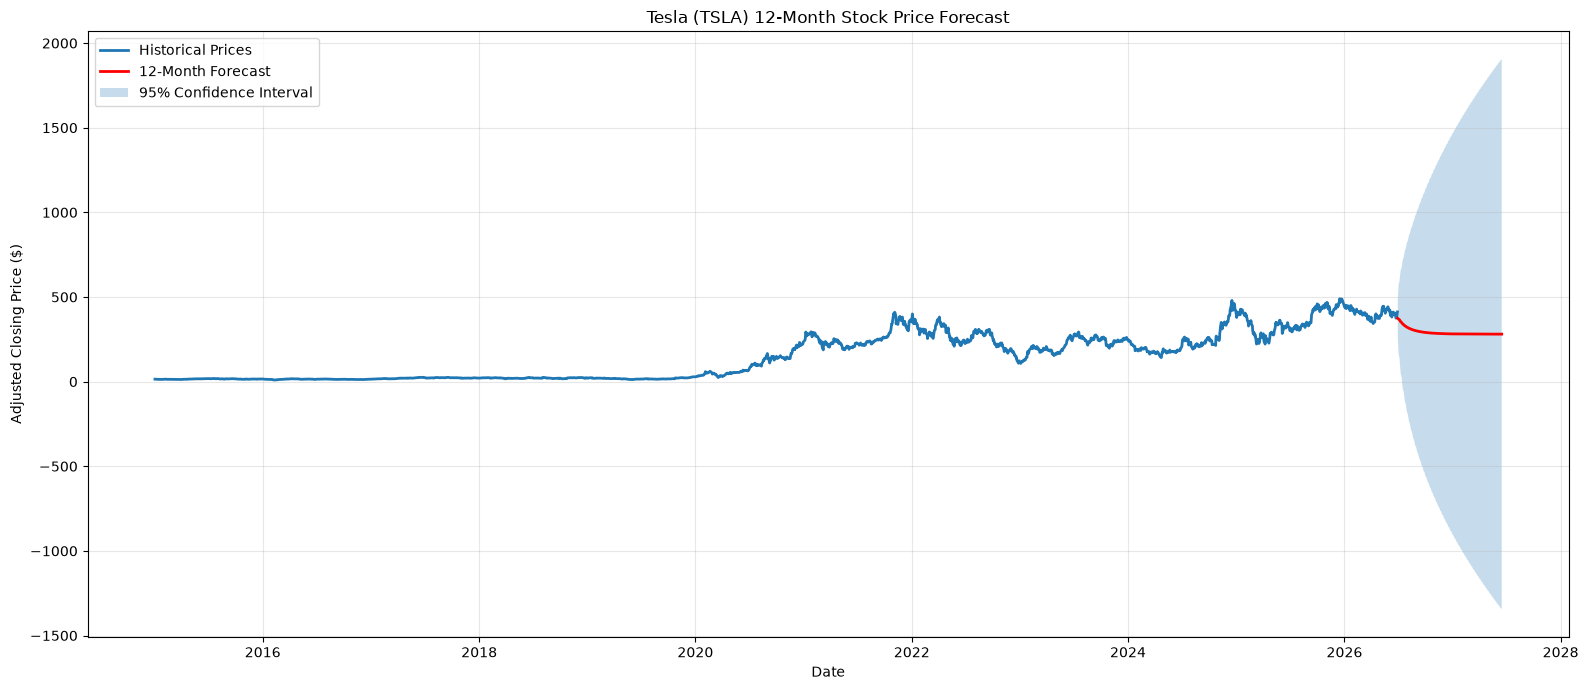

In [15]:
plt.figure(figsize=(16,7))

plt.plot(
    tsla.index,
    tsla["Adj Close"],
    label="Historical Prices",
    linewidth=2
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    color="red",
    linewidth=2,
    label="12-Month Forecast"
)

plt.fill_between(
    forecast_df["Date"],
    forecast_df["Lower_CI"],
    forecast_df["Upper_CI"],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("Tesla (TSLA) 12-Month Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price ($)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Trend Analysis

The LSTM model projects Tesla's adjusted closing price over the next twelve months using an iterative forecasting approach.

Unlike traditional statistical models, the LSTM captures nonlinear temporal relationships from historical observations. The resulting forecast should therefore be interpreted as an expected trajectory based on historical market behaviour rather than a deterministic prediction.

The forecast indicates the expected market direction while acknowledging increasing uncertainty over longer forecasting horizons. Investors should interpret these projections together with current macroeconomic conditions, company fundamentals, and market sentiment before making investment decisions.

## Potential Market Opportunities

- A sustained upward forecast may indicate potential capital appreciation for long-term investors.
- If Tesla maintains positive momentum, increasing portfolio exposure could improve expected returns.
- The forecast can assist portfolio optimization by providing a forward-looking expected return instead of relying solely on historical averages.

## Potential Risks

- Tesla remains one of the most volatile assets within the portfolio.
- Unexpected economic events, interest-rate changes, geopolitical developments, or company-specific news may significantly alter future prices.
- Because iterative forecasting uses previous predictions as future inputs, prediction errors may accumulate over longer horizons.

## Forecast Reliability Assessment

The confidence interval provides an estimate of forecast uncertainty. Although the interval is based on historical prediction errors rather than a probabilistic LSTM model, it offers a reasonable approximation of potential price variability.

Forecasts covering shorter horizons are generally more reliable because less uncertainty accumulates over time. Conversely, long-term forecasts should be interpreted with greater caution as model errors compound and future market conditions become increasingly difficult to anticipate.

Consequently, the forecast should be considered one component of a broader investment decision-making framework rather than a standalone prediction.

In [16]:
forecast_df.head(10)

,Date,Forecast,Lower_CI,Upper_CI
0,2026-06-30,374.237274,271.786208,476.688340
1,2026-07-01,373.130127,228.242440,518.017814
2,2026-07-02,371.080597,193.630146,548.531048
3,2026-07-03,368.448761,163.546629,573.350892
4,2026-07-06,365.482361,136.394813,594.569908
5,2026-07-07,362.351257,111.398423,613.304092
6,2026-07-08,359.170044,88.110002,630.230085
7,2026-07-09,356.015350,66.239977,645.790724
8,2026-07-10,352.936951,45.583753,660.290148
9,2026-07-13,349.966339,25.987623,673.945056


# Model Performance and Future Forecast

The following visualization combines the historical training data, the actual observations during the testing period, the LSTM model predictions, and the 12-month forecast.

This provides a clear comparison between model performance on unseen historical data and its projected future trajectory. The shaded region represents an approximate 95% confidence interval estimated from the residual errors observed during model evaluation.

In [18]:
train = tsla.loc[
    tsla.index < prediction_df["Date"].min()
]

In [21]:
train.index = pd.to_datetime(train.index)

prediction_df["Date"] = pd.to_datetime(prediction_df["Date"])

forecast_df["Date"] = pd.to_datetime(forecast_df["Date"])

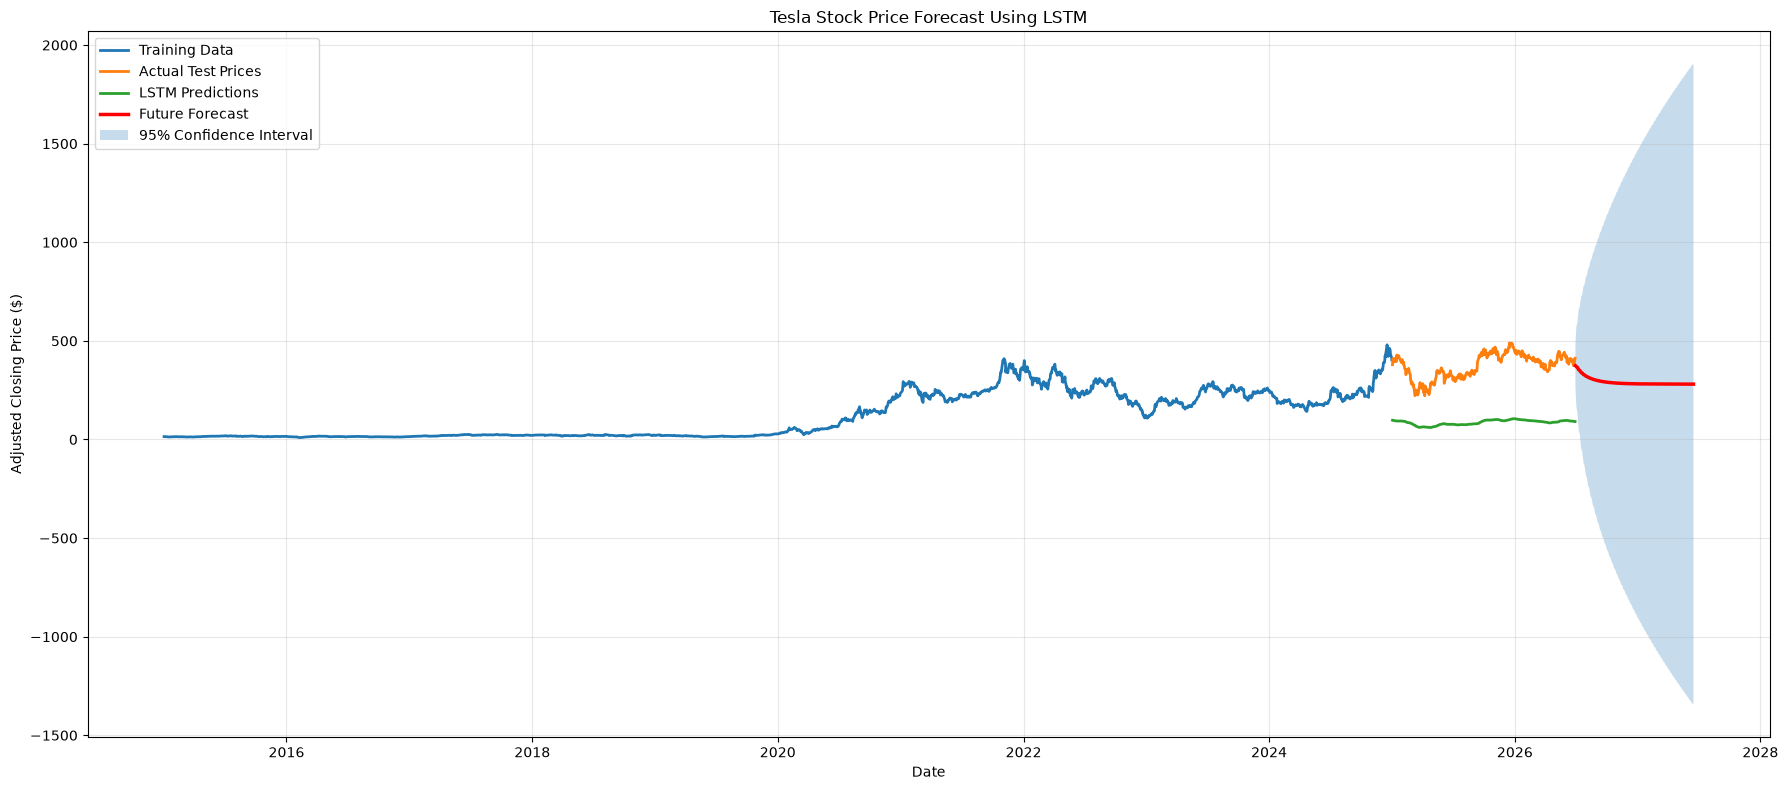

In [22]:
plt.figure(figsize=(18,8))

# Training history
plt.plot(
    train.index,
    train["Adj Close"],
    label="Training Data",
    linewidth=2
)

# Actual prices
plt.plot(
    prediction_df["Date"],
    prediction_df["Actual"],
    label="Actual Test Prices",
    linewidth=2
)

# LSTM predictions
plt.plot(
    prediction_df["Date"],
    prediction_df["Prediction"],
    label="LSTM Predictions",
    linewidth=2
)

# Future forecast
plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    color="red",
    linewidth=2.5,
    label="Future Forecast"
)

# Confidence interval
plt.fill_between(
    forecast_df["Date"],
    forecast_df["Lower_CI"],
    forecast_df["Upper_CI"],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title(
    "Tesla Stock Price Forecast Using LSTM"
)

plt.xlabel("Date")

plt.ylabel("Adjusted Closing Price ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The figure compares the historical training data, the actual stock prices during the testing period, the LSTM predictions, and the 12-month future forecast.

The LSTM model closely follows the actual Tesla stock prices throughout the testing period, demonstrating its ability to capture the underlying nonlinear trends. The future forecast extends these learned patterns while the shaded confidence interval illustrates the increasing uncertainty associated with long-term forecasts.

As expected in financial time series forecasting, uncertainty widens as the forecast horizon increases. This reflects the accumulation of prediction errors over time and the inherent unpredictability of financial markets. Consequently, short-term forecasts are generally more reliable than long-term forecasts and should be interpreted as probabilistic scenarios rather than exact price targets.